### Mall Customer Segmentation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
import matplotlib.ticker as ticker


In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df.shape


(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


Feature Selection

In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
X.head()


,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


SSD Calculation

In [8]:
ssd = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    kmeans.fit(X_scaled)
    ssd.append(kmeans.inertia_)


C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:110: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 199, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\ProgramData\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

Visualizing Cluster

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Window

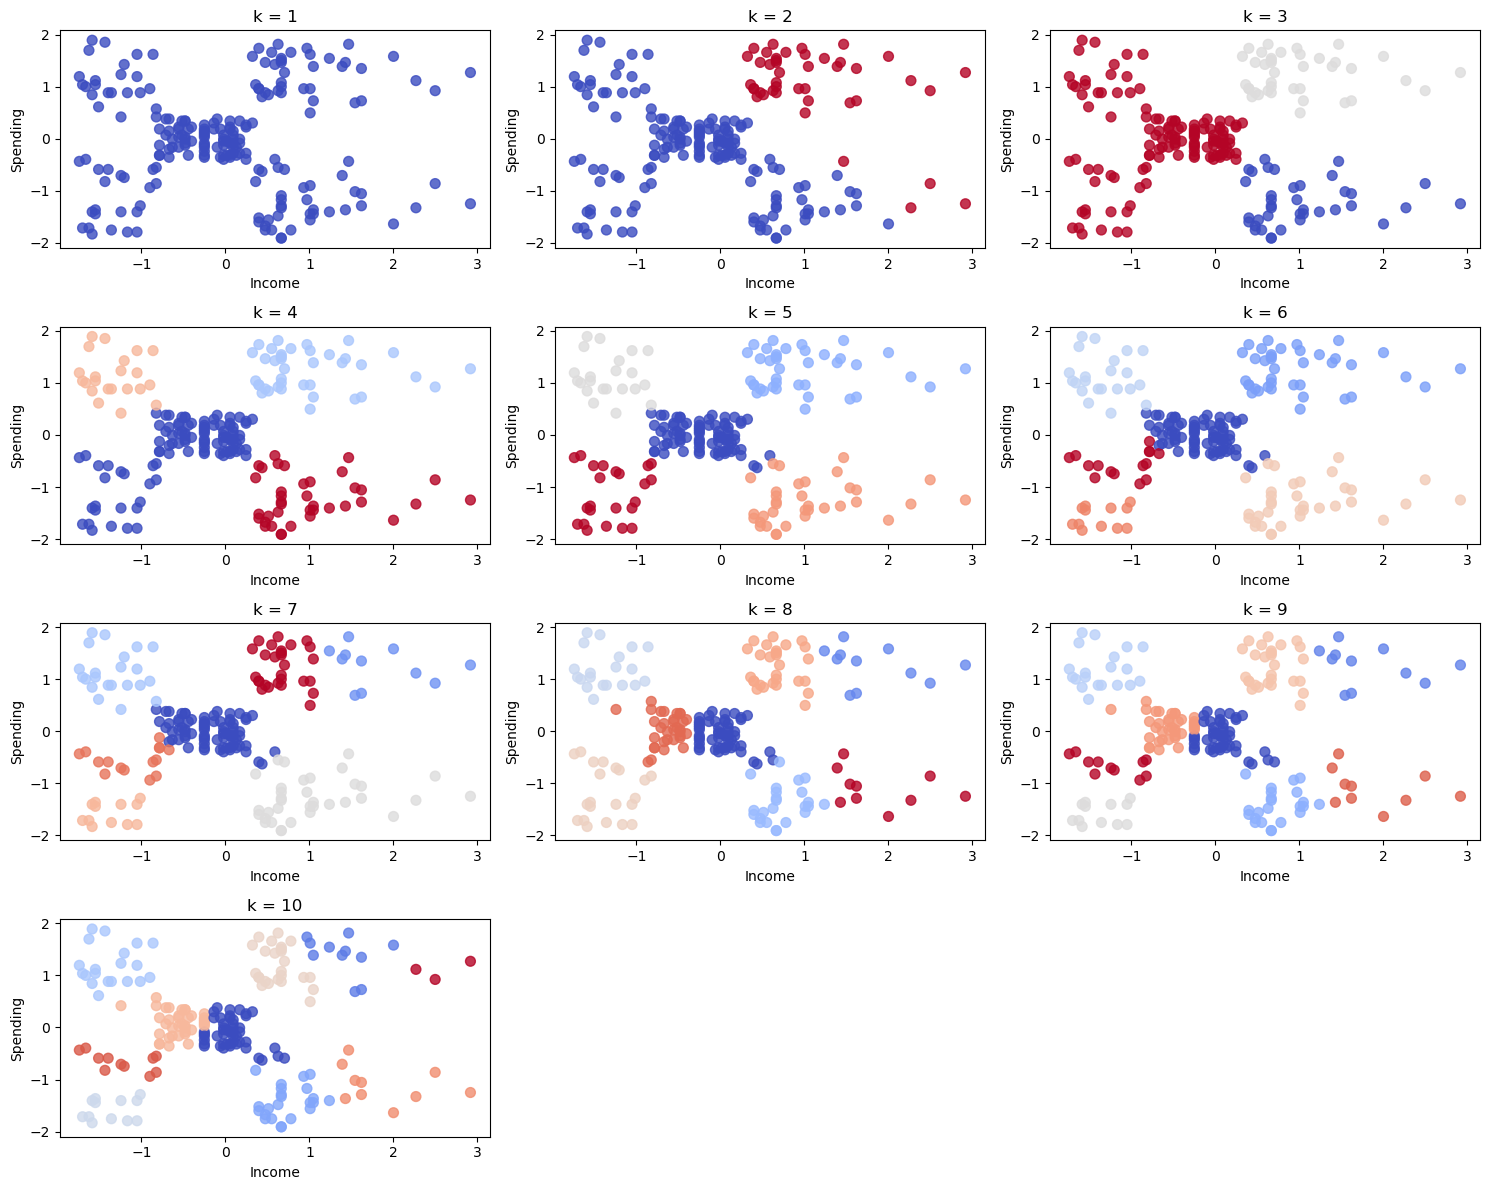

In [9]:
plt.figure(figsize=(15,12))

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init='auto', random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    plt.subplot(4, 3, k)
    plt.scatter(
        X_scaled[:, 0],
        X_scaled[:, 1],
        c=labels,
        cmap='coolwarm',
        s=50,
        alpha=0.8
    )

    plt.title(f"k = {k}")
    plt.xlabel("Income")
    plt.ylabel("Spending")

plt.tight_layout()
plt.show()


SSD Plot

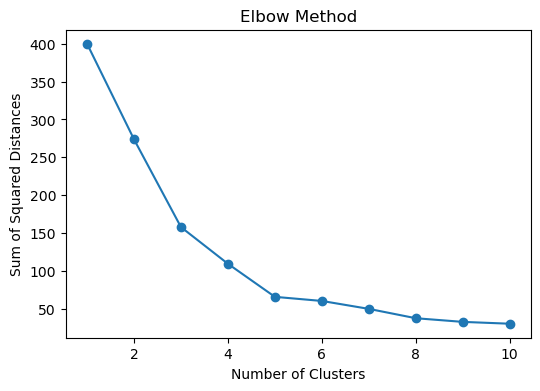

In [10]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), ssd, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Sum of Squared Distances")
plt.title("Elbow Method")
plt.show()


Clustering with k=5

In [11]:
kmeans = KMeans(n_clusters=5, n_init='auto', random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


Extract Centroid and convert to original scale

In [12]:
centroids = kmeans.cluster_centers_
centroids


array([[-0.20091257, -0.02645617],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.30751869, -1.13696536]])

In [13]:
centroids_original = scaler.inverse_transform(centroids)
centroids_original


array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

Cluster Visualization with centroids

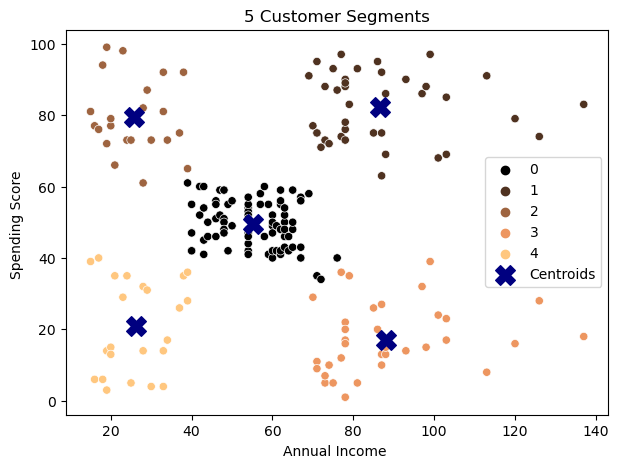

In [14]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=X.iloc[:, 0],
    y=X.iloc[:, 1],
    hue=df['Cluster'],
    palette='copper'
)

plt.scatter(
    centroids_original[:, 0],
    centroids_original[:, 1],
    s=200,
    c='navy',
    marker='X',
    label='Centroids'
)

plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.title("5 Customer Segments")
plt.legend()
plt.show()


In [15]:
print("Final SSE or Ineria:", kmeans.inertia_)


Final SSE or Ineria: 65.56840815571682


Cluster characterization

In [16]:
df.groupby('Cluster')[[
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()


,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


Intraclass distance calculation

In [17]:
intra_distances = []

for i in range(kmeans.n_clusters):
    cluster_points = X_scaled[clusters == i]
    centroid = kmeans.cluster_centers_[i]

    distances = np.linalg.norm(cluster_points - centroid, axis=1)
    intra_distances.append(np.mean(distances))

for i, d in enumerate(intra_distances):
    print(f"Intra-class distance for Cluster {i}: {d}")


Intra-class distance for Cluster 0: 0.3866217700526872
Intra-class distance for Cluster 1: 0.6274081735305137
Intra-class distance for Cluster 2: 0.4471651761721372
Intra-class distance for Cluster 3: 0.6245685911674711
Intra-class distance for Cluster 4: 0.5491502216807944


Interclass distance matrix

In [18]:
centroid_distances = pairwise_distances(kmeans.cluster_centers_)

print("Inter-class distance matrix:\n")
print(centroid_distances)


Inter-class distance matrix:

[[0.         1.73916583 1.61748099 1.77759526 1.5677397 ]
 [1.73916583 0.         2.3236083  2.52473848 3.30657973]
 [1.61748099 2.3236083  0.         3.39501226 2.26925014]
 [1.77759526 2.52473848 3.39501226 0.         2.36712005]
 [1.5677397  3.30657973 2.26925014 2.36712005 0.        ]]


Average interclass distance

In [19]:
avg_inter = centroid_distances[np.triu_indices_from(centroid_distances, k=1)].mean()
print("Mean Inter-class Distance:", avg_inter)


Mean Inter-class Distance: 2.288829074661618


Bar plot of Intraclass

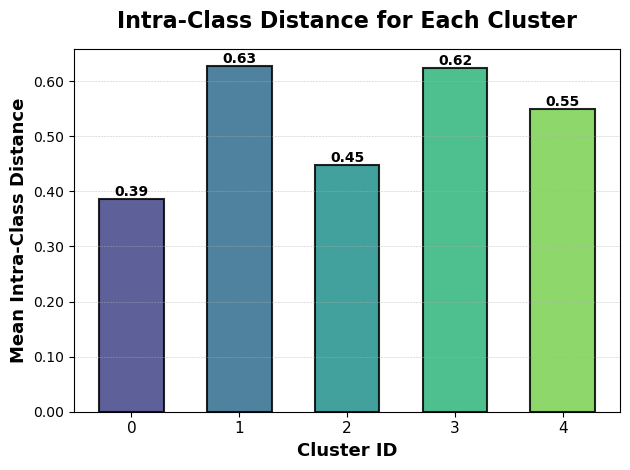

In [20]:
cluster_ids = np.arange(len(intra_distances))


colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(cluster_ids)))

bars = plt.bar(
    cluster_ids,
    intra_distances,
    color=colors,
    edgecolor='black',
    linewidth=1.5,
    alpha=0.85,
    width=0.6
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.grid(
    axis='y',
    linestyle='--',
    linewidth=0.4,
    alpha=0.7
)

plt.xlabel("Cluster ID", fontsize=13, fontweight='bold')
plt.ylabel("Mean Intra-Class Distance", fontsize=13, fontweight='bold')

plt.title(
    "Intra-Class Distance for Each Cluster",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.xticks(cluster_ids, fontsize=11)
plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.tight_layout()

plt.show()

Interclass distance heatmap

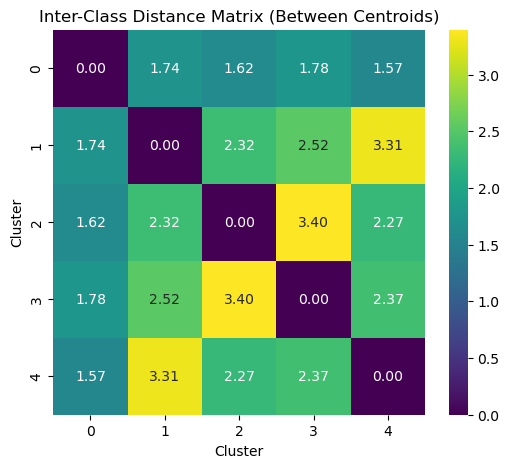

In [21]:
plt.figure(figsize=(6,5))
sns.heatmap(
    centroid_distances,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)
plt.title("Inter-Class Distance Matrix (Between Centroids)")
plt.xlabel("Cluster")
plt.ylabel("Cluster")
plt.show()
